In [1]:
import pandas as pd
import duckdb
import numpy as np

conn = duckdb.connect()


In [2]:
df = pd.read_parquet("data/faculty-salaries.parquet")


### Origional Data Shape

In [3]:
df.count()

name                5345243
job                 5345131
department              137
base                5345131
overtime            5345131
other               5345131
ual                       0
benefitsee                0
benefitser                0
benefitsdc                0
notes                 28494
totalpay            5345115
totalbenefits       5345131
totalpaybenefits    5345128
year                5345243
dtype: int64

### Data Cleanup
* Remove empty Cols
* Drop missing names and pays
* Base salary must be more than 10k
* Make all strings lowercase

In [4]:
# Drop empty cols: ual, benefitsee, benefitser, and benefitsdc
df = df.drop(columns=['ual', 'benefitsee', 'benefitser', 'benefitsdc', 'notes'])

# Drop rows missing name or totalpay
df = df.dropna(subset=['name', 'totalpay'])
# filter to base salary > 10k
df = df[df['totalpay'] >= 10000]

# Adding this for outliers I dont want to include
df = df[df['totalpay'] <= 400000]
# make everything lowercase for consistency
df = df.map(lambda s: s.lower() if isinstance(s, str) else s)

df.count()


name                3516705
job                 3516705
department               25
base                3516705
overtime            3516705
other               3516705
totalpay            3516705
totalbenefits       3516705
totalpaybenefits    3516705
year                3516705
dtype: int64

* Since department data is missing for the most part and parcially covered in job we will be removing that as well

In [5]:
df = df.drop(columns=['department'])

### Looking at *Educator* Jobs

In [6]:
duckdb.sql("""
    SELECT 
        job,
        COUNT(*) AS employee_count,
        ROUND(AVG(totalpaybenefits)) AS avg_pay
    FROM df
    WHERE 
        job ILIKE '%prof%'
        OR job ILIKE '%instruct%'
        OR job ILIKE '%faculty%'
        OR job ILIKE '%lectur%'
        OR job ILIKE '%adjunct%'
    GROUP BY job
    ORDER BY employee_count DESC""").df()

,job,employee_count,avg_pay
0,lecturer - academic year,170191,49319.0
1,instructional faculty - academic year,145054,123397.0
2,prof-ay,42950,224990.0
3,hs asst clin prof-hcomp,19471,232435.0
4,assoc prof-ay,18691,151058.0
...,...,...,...
1656,prof exp - dw instruction,1,197689.0
1657,agricultural science instructor,1,163052.0
1658,professor-fashion,1,186654.0
1659,professor-learning assistance,1,202367.0


### Narrow the df to only educational faculty with totalpay >= 10k

In [7]:
df = duckdb.sql("""
    SELECT *
    FROM df
    WHERE 
        job ILIKE '%prof%'
        OR job ILIKE '%instruct%'
        OR job ILIKE '%faculty%'
        OR job ILIKE '%lectur%'
        OR job ILIKE '%adjunct%'
        AND totalpay >= 10000
        """).df()

In [8]:
duckdb.sql(""" 
    CREATE TABLE faculty_salaries AS
    SELECT *
    FROM df
""")

#### Investigating Faculty with a tenure of at lease 10 years 
First I want just faculty who've been around for 10 years and their pay

In [9]:
duckdb.sql("""
WITH yearly_pay AS (
    SELECT name, job, year, SUM(totalpay) AS pay
    FROM faculty_salaries
    GROUP BY name, job, year
),
oldtimers AS (
    -- Group for consecutive years
    SELECT name, job, year, pay,
        year - CAST(ROW_NUMBER() OVER (PARTITION BY name ORDER BY year) AS INT) AS grp
    FROM yearly_pay
),
valid_groups AS (
    -- People who have had 10 consecutive years of pay
    SELECT name, grp
    FROM oldtimers
    GROUP BY name, grp
    HAVING COUNT(*) >= 10
)
SELECT oldtimers.name, oldtimers.job, oldtimers.year, ROUND(oldtimers.pay) AS pay
FROM oldtimers
JOIN valid_groups 
    ON oldtimers.name = valid_groups.name 
    AND oldtimers.grp = valid_groups.grp
ORDER BY oldtimers.name, oldtimers.year
""").df()

,name,job,year,pay
0,a dee williams,instructional faculty - academic year,2011,68328.0
1,a dee williams,instructional faculty - academic year,2012,69228.0
2,a dee williams,instructional faculty - academic year,2013,67812.0
3,a dee williams,instructional faculty - academic year,2014,75699.0
4,a dee williams,instructional faculty - academic year,2015,80975.0
...,...,...,...,...
203216,zvonimir hlousek,instructional faculty - academic year,2016,112272.0
203217,zvonimir hlousek,instructional faculty - academic year,2017,101110.0
203218,zvonimir hlousek,instructional faculty - academic year,2018,102258.0
203219,zvonimir hlousek,instructional faculty - academic year,2019,107229.0


* Get faculty who have been around a long time get their starting pay and ending pay

In [10]:
pay_df = duckdb.sql("""
WITH yearly_pay AS (
    SELECT name, job, year, SUM(totalpay) AS pay
    FROM faculty_salaries
    GROUP BY name, job, year
),
collision_check AS (
    SELECT name, job, year, pay,
        COUNT(*) OVER (PARTITION BY name, year) AS year_total
    FROM yearly_pay  
),
collision_purged AS (
    SELECT name, job, year, pay
    FROM collision_check
    WHERE year_total = 1
),
oldtimers AS (
    SELECT name, year, pay, job,
        year - CAST(ROW_NUMBER() OVER (PARTITION BY name ORDER BY year) AS INT) AS grp
    FROM collision_purged
),
consecutive_years AS (
    SELECT 
        name,
        MIN(year) AS start_year,
        MAX(year) AS end_year,
        MIN(job) AS starting_job,
        MAX(job) AS ending_job,
        
        arg_min(pay, year) AS starting_pay,
        arg_max(pay, year) AS ending_pay
    FROM oldtimers
    GROUP BY name, job, grp
    HAVING COUNT(*) >= 10
)
SELECT 
    name,
    starting_job,
    ending_job,
    start_year,
    end_year,
    starting_pay,
    ending_pay
    FROM consecutive_years
    ORDER BY ending_pay DESC
""").df()

pay_df

,name,starting_job,ending_job,start_year,end_year,starting_pay,ending_pay
0,min zhao,prof-hcomp,prof-hcomp,2013,2024,190607.0,400000.00
1,neal halfon,prof-hcomp,prof-hcomp,2013,2024,297710.0,400000.00
2,hilary hoynes,prof-ay,prof-ay,2013,2023,129304.0,399972.00
3,dejan markovic,prof-ay-b/e/e,prof-ay-b/e/e,2014,2024,172494.0,399916.00
4,mark van der laan,prof-ay,prof-ay,2013,2023,289026.0,399616.00
...,...,...,...,...,...,...,...
13420,george d baldwin,instructional faculty - academic year,instructional faculty - academic year,2011,2023,91164.0,10065.15
13421,robert e wall,lecturer - academic year,lecturer - academic year,2011,2021,34911.0,10063.20
13422,wayne r pinnell,lecturer - academic year,lecturer - academic year,2011,2021,10687.2,10042.20
13423,wyndell h merritt ii,lecturer - academic year,lecturer - academic year,2013,2024,10642.0,10029.60


#### Median Difference Between Starting and Ending Pay

In [11]:
pay_df['pay_difference'] = pay_df['ending_pay'] - pay_df['starting_pay']

median_diff = pay_df['pay_difference'].median()
mean_diff = pay_df['pay_difference'].mean()

print(f"Median Pay Difference: ${median_diff:,.2f}")
print(f"Mean Pay Difference: ${mean_diff:,.2f}")
# Starting pay max and max Ending pay
print(f"Max Starting Pay: ${pay_df['starting_pay'].max():,.2f}")
print(f"Max Ending Pay: ${pay_df['ending_pay'].max():,.2f}")

Median Pay Difference: $43,458.83
Mean Pay Difference: $43,279.26
Max Starting Pay: $384,226.00
Max Ending Pay: $400,000.00


In [12]:
# Only include people whos ending pay is greater than starting pay
pay_df = pay_df[pay_df['ending_pay'] > pay_df['starting_pay']]


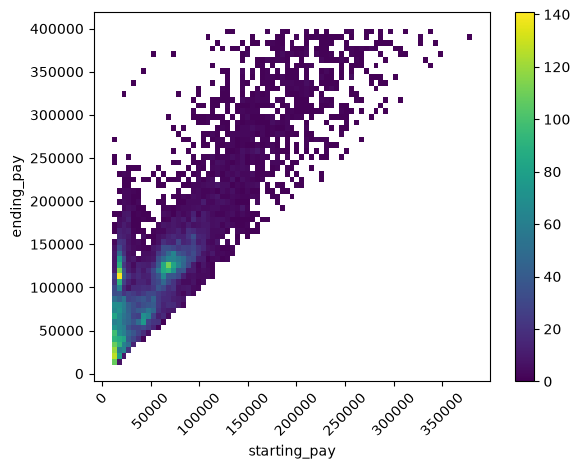

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data=pay_df, x="starting_pay", y="ending_pay", cbar=True, cmap="viridis")
plt.xticks(rotation=45)
plt.show()

Names are not unique... current solution, drop name collisions

### Overall Pay Stats

In [14]:
col = df["totalpay"]

col.mean()
col.median()                                       # center — robust
col.std()    
col.min()
col.max()                                        # spread — sensitive
print("Mean:", col.mean())
print("Median:", col.median())
print("Standard Deviation:", col.std())
print("Minimum:", col.min())
print("Maximum:", col.max())
print("IQR:", col.quantile(0.75) - col.quantile(0.25))


Mean: 102644.44541955715
Median: 80798.94
Standard Deviation: 83288.24110355088
Minimum: 10000.0
Maximum: 400000.0
IQR: 97709.79749999999
